<a href="https://colab.research.google.com/github/Salimam00/PISA2022-Math-Achievement-Kazakhstan/blob/main/PISA_2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!wget -O /content/SCH_QQQ_SPSS.zip https://webfs.oecd.org/pisa2022/SCH_QQQ_SPSS.zip
!unzip -o /content/SCH_QQQ_SPSS.zip -d /content/SCH_QQQ_SPSS
!ls /content/SCH_QQQ_SPSS

--2026-08-21 10:21:00--  https://webfs.oecd.org/pisa2022/SCH_QQQ_SPSS.zip
Resolving webfs.oecd.org (webfs.oecd.org)... 78.41.128.157
Connecting to webfs.oecd.org (webfs.oecd.org)|78.41.128.157|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6228625 (5.9M) [application/x-zip-compressed]
Saving to: ‘/content/SCH_QQQ_SPSS.zip’

/content/SCH_QQQ_SP 100%[===================>]   5.94M  5.82MB/s    in 1.0s    

2026-08-21 10:21:01 (5.82 MB/s) - ‘/content/SCH_QQQ_SPSS.zip’ saved [6228625/6228625]

Archive:  /content/SCH_QQQ_SPSS.zip
  inflating: /content/SCH_QQQ_SPSS/CY08MSP_SCH_QQQ.SAV  
CY08MSP_SCH_QQQ.SAV


In [6]:
!pip install pyreadstat -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 27.9 MB/s eta 0:00:00


In [7]:
import pyreadstat
import pandas as pd

path = "/content/SCH_QQQ_SPSS/CY08MSP_SCH_QQQ.SAV"  # поправьте имя файла, если в шаге 3 оно отличалось

_, meta = pyreadstat.read_sav(path, metadataonly=True)
print("Число переменных:", len(meta.column_names))

var_list = pd.DataFrame({"variable": meta.column_names, "label": meta.column_labels})
var_list.to_csv("/content/drive/MyDrive/PISA2022/SCH_variable_list.csv", index=False)
print("Сохранено на Диск: /content/drive/MyDrive/PISA2022/SCH_variable_list.csv")

Число переменных: 431
Сохранено на Диск: /content/drive/MyDrive/PISA2022/SCH_variable_list.csv


In [6]:
from google.colab import files
files.download("/content/drive/MyDrive/PISA2022/SCH_variable_list.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import pyreadstat
import pandas as pd

path = "/content/SCH_QQQ_SPSS/CY08MSP_SCH_QQQ.SAV"  # поправьте, если файл лежит в другом месте

sch_cols = [
    # ключ для связи с ученическим файлом + фильтр по стране
    "CNTSCHID", "CNT",

    # тип и контекст школы
    "SCHLTYPE", "PRIVATESCH", "SC001Q01TA", "SCHSIZE", "SCHSEL",

    # учителя математики: нагрузка и квалификация
    "STRATIO", "SMRATIO", "PROPMATH", "PROATCE", "MTTRAIN",

    # цифровая инфраструктура и политика школы (продолжение ICTHOME/ICTSCH/ICTSUBJ на уровень школы)
    "RATCMP1", "RATCMP2", "RATTAB", "DIGDVPOL", "DIGPREP",

    # руководство и автономия школы
    "SCHAUTO", "EDULEAD", "INSTLEAD",

    # школьный климат (параллель DISCLIM на уровне ученика)
    "NEGSCLIM", "STUBEHA", "TEACHBEHA",

    # размер класса, группировка по способностям, доп. курсы математики
    "MCLSIZE", "CLSIZE", "ABGMATH", "MATHEXC",

    # доля учащихся из социально незащищённых семей (школьная композиция СЭС)
    "SC211Q03JA",

    # веса для двухуровневой модели
    "W_SCHGRNRABWT", "SENWT",
]

df, meta = pyreadstat.read_sav(path, usecols=sch_cols)
df_kaz = df[df["CNT"] == "KAZ"].copy()
print(df_kaz.shape)   # ожидаем (571, len(sch_cols))

out_path = "/content/drive/MyDrive/PISA2022/KAZ_SCH_subset.csv"
df_kaz.to_csv(out_path, index=False)
print("сохранено:", out_path)

from google.colab import files
files.download(out_path)

(571, 30)
сохранено: /content/drive/MyDrive/PISA2022/KAZ_SCH_subset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!pip install pyreadstat -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 60.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [9]:
path = '/content/drive/MyDrive/PISA2022/CY08MSP_STU_QQQ.SAV'  # ваш путь

In [10]:
import pyreadstat

_, meta = pyreadstat.read_sav(path, metadataonly=True)

# Название переменной (label)
print("Variable label:", meta.column_names_to_labels.get('ST004D01T'))

# Value labels — то, что нам нужно
print("Value labels:", meta.variable_value_labels.get('ST004D01T'))

PyreadstatError: File /content/drive/MyDrive/PISA2022/CY08MSP_STU_QQQ.SAV does not exist!

In [11]:
from google.colab import drive
drive.mount('/content/drive')

!find /content/drive/MyDrive -iname "*STU_QQQ*" 2>/dev/null

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/CY08MSP_STU_QQQ.SAV


In [12]:
import pyreadstat

path = '/content/drive/MyDrive/CY08MSP_STU_QQQ.SAV'
_, meta = pyreadstat.read_sav(path, metadataonly=True)

print("Variable label:", meta.column_names_to_labels.get('ST004D01T'))
print("Value labels:", meta.variable_value_labels.get('ST004D01T'))

Variable label: Student (Standardized) Gender
Value labels: {1.0: 'Female', 2.0: 'Male', 5.0: 'Valid Skip', 7.0: 'Not Applicable', 8.0: 'Invalid', 9.0: 'No Response'}


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
N (Казахстан, PV1MATH и W_FSTUWT не пропущены) = 19769
Взвешенное среднее PV1MATH (KAZ) = 425.5


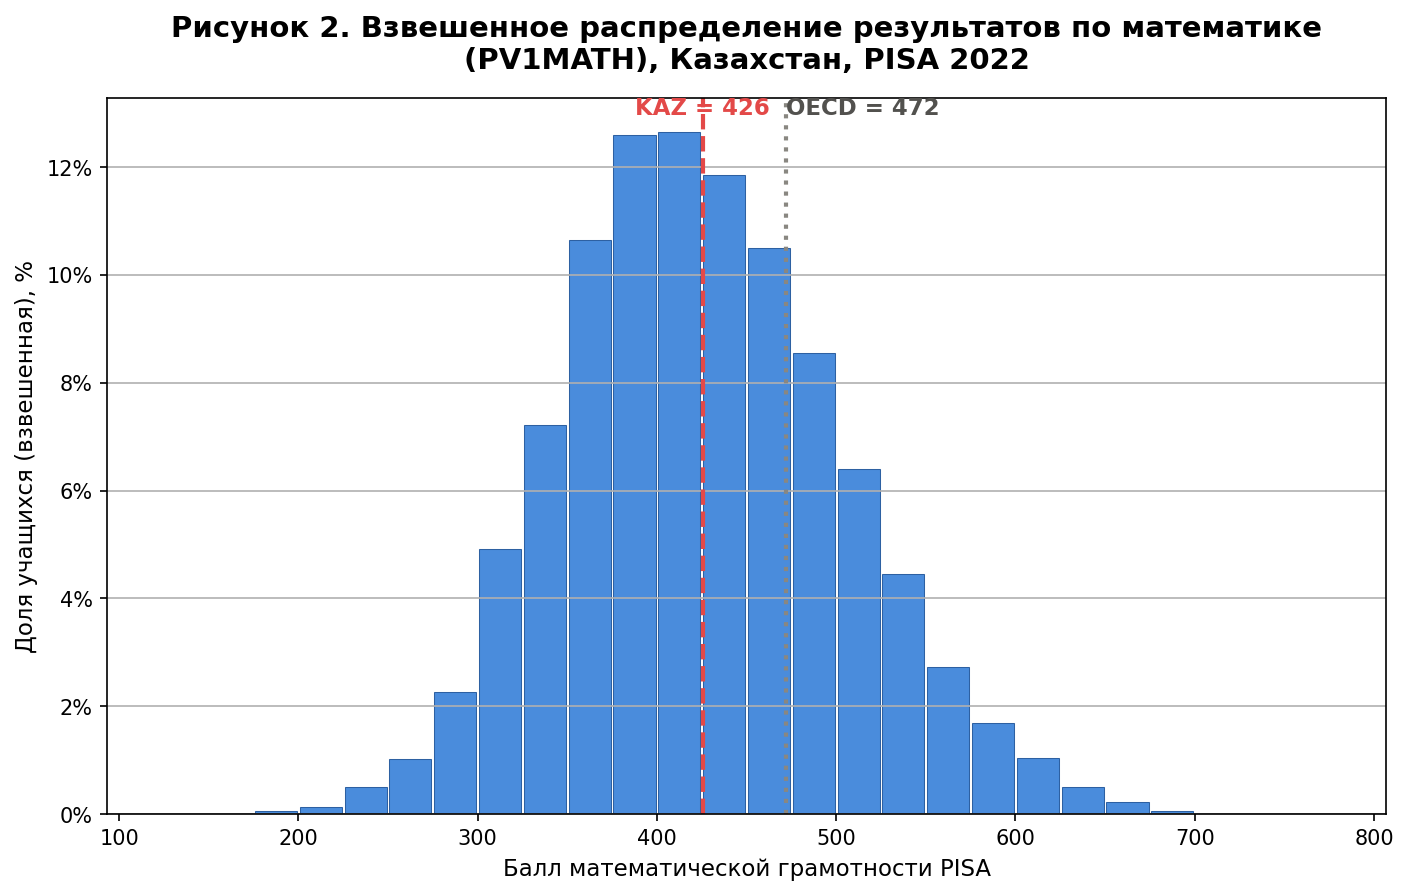

In [13]:
# ============================================================
# Рисунок 2. Взвешенное распределение результатов по математике
# (PV1MATH), Казахстан, PISA 2022 (N = 19 769)
# ============================================================

# --- 0. Установка зависимостей (если ещё не установлены) ---
!pip install pyreadstat -q

import pyreadstat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- 1. Путь к файлу (замените на свой, если отличается) ---
path = '/content/drive/MyDrive/CY08MSP_STU_QQQ.SAV'

# Если Drive ещё не подключён:
from google.colab import drive
drive.mount('/content/drive')

# --- 2. Читаем только нужные переменные (быстрее, чем весь файл) ---
usecols = ['CNT', 'PV1MATH', 'W_FSTUWT']
df, meta = pyreadstat.read_sav(path, usecols=usecols)

# --- 3. Фильтруем только Казахстан ---
kaz = df[df['CNT'] == 'KAZ'].copy()
kaz = kaz.dropna(subset=['PV1MATH', 'W_FSTUWT'])

n = len(kaz)
print(f"N (Казахстан, PV1MATH и W_FSTUWT не пропущены) = {n}")

# --- 4. Взвешенное среднее по Казахстану (для референсной линии) ---
kaz_mean = np.average(kaz['PV1MATH'], weights=kaz['W_FSTUWT'])
print(f"Взвешенное среднее PV1MATH (KAZ) = {kaz_mean:.1f}")

# Официальное среднее по OECD (OECD, 2023a) — фиксированное референсное значение
oecd_mean = 472

# --- 5. Взвешенная гистограмма, интервалы по 25 баллов ---
bin_width = 25
lo = np.floor(kaz['PV1MATH'].min() / bin_width) * bin_width
hi = np.ceil(kaz['PV1MATH'].max() / bin_width) * bin_width
bins = np.arange(lo, hi + bin_width, bin_width)

weighted_counts, bin_edges = np.histogram(
    kaz['PV1MATH'], bins=bins, weights=kaz['W_FSTUWT']
)
# переводим в проценты от взвешенной суммы (Σ W_FSTUWT)
weighted_pct = weighted_counts / kaz['W_FSTUWT'].sum() * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# --- 6. Построение графика ---
fig, ax = plt.subplots(figsize=(11, 6.2), dpi=150)

ax.bar(
    bin_centers, weighted_pct, width=bin_width * 0.94,
    color='#2a78d6', edgecolor='#184f95', linewidth=0.5, alpha=0.85
)

# референсные линии
ax.axvline(kaz_mean, color='#e34948', linestyle='--', linewidth=2)
ax.text(kaz_mean, ax.get_ylim()[1]*0.97 if ax.get_ylim()[1] else 0,
        f'KAZ = {kaz_mean:.0f}', color='#e34948', fontsize=11,
        fontweight='bold', ha='center', va='bottom')

ax.axvline(oecd_mean, color='#898781', linestyle=':', linewidth=2)
ax.text(oecd_mean, ax.get_ylim()[1]*0.97 if ax.get_ylim()[1] else 0,
        f'OECD = {oecd_mean}', color='#52514e', fontsize=11,
        fontweight='bold', ha='left', va='bottom')

# подписи и оформление
ax.set_title(
    'Рисунок 2. Взвешенное распределение результатов по математике\n'
    '(PV1MATH), Казахстан, PISA 2022',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Балл математической грамотности PISA', fontsize=11)
ax.set_ylabel('Доля учащихся (взвешенная), %', fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.grid(axis='y') # Fixed: added 'y' to specify grid on y-axis

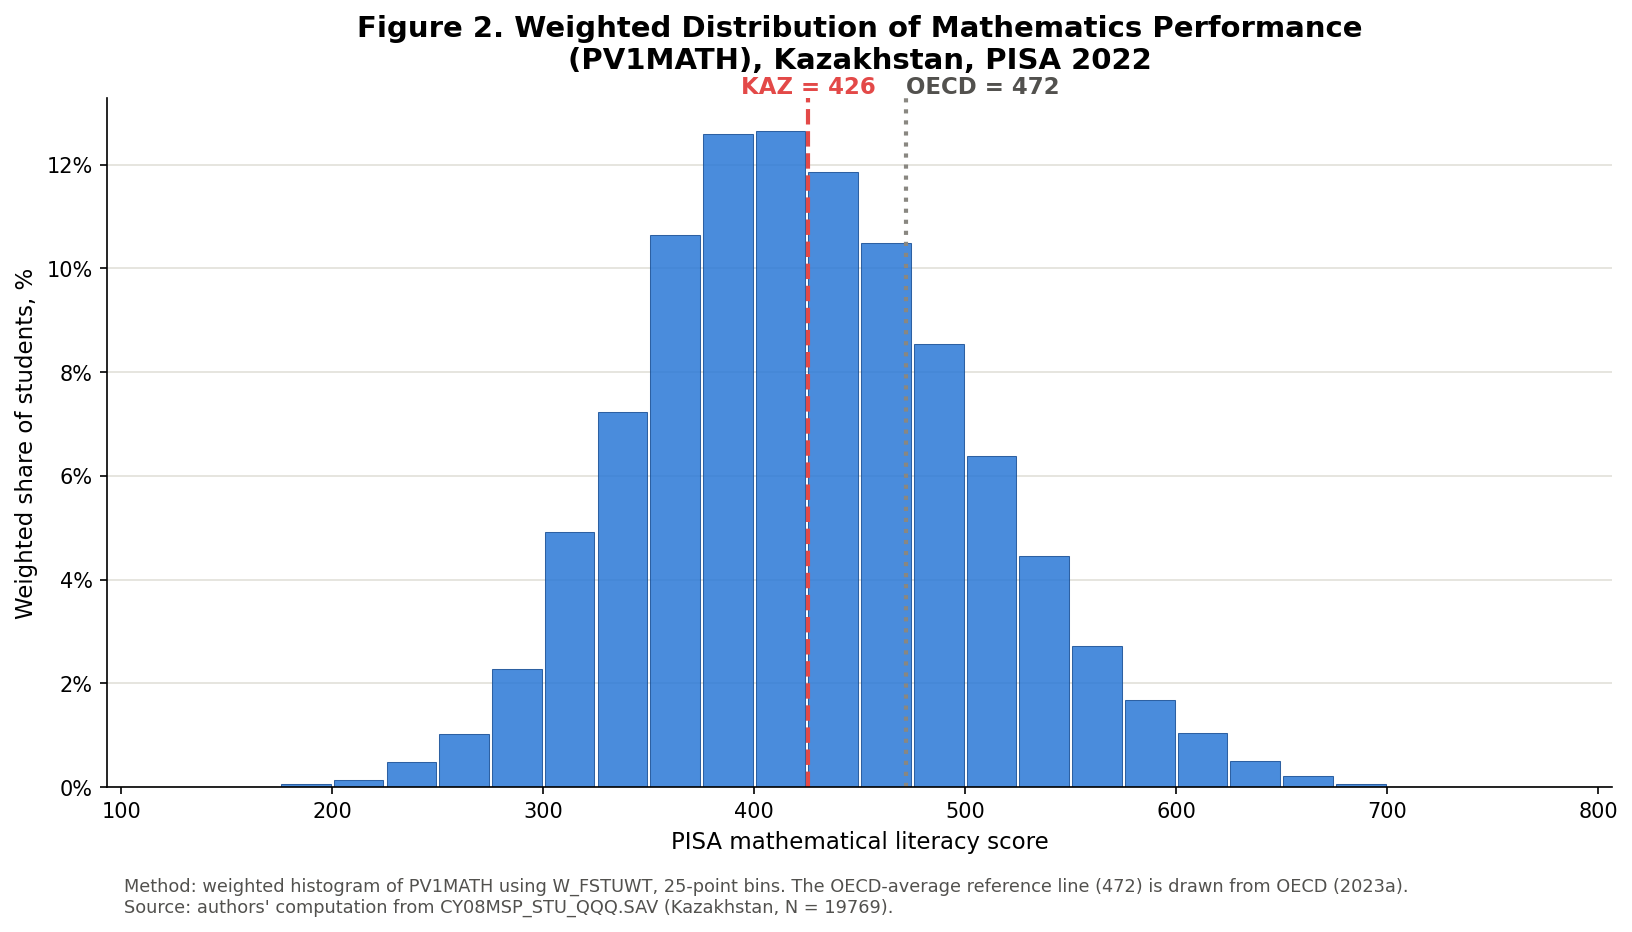

Saved: /content/figure2_distribution_en.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# --- Weighted histogram, 25-point bins ---
bin_width = 25
lo = np.floor(kaz['PV1MATH'].min() / bin_width) * bin_width
hi = np.ceil(kaz['PV1MATH'].max() / bin_width) * bin_width
bins = np.arange(lo, hi + bin_width, bin_width)
weighted_counts, bin_edges = np.histogram(
    kaz['PV1MATH'], bins=bins, weights=kaz['W_FSTUWT']
)
weighted_pct = weighted_counts / kaz['W_FSTUWT'].sum() * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# --- Build the plot ---
fig, ax = plt.subplots(figsize=(11, 6.2), dpi=150)
ax.bar(
    bin_centers,
    weighted_pct,
    width=bin_width * 0.94,
    color='#2a78d6',
    edgecolor='#184f95',
    linewidth=0.5,
    alpha=0.85
)
ax.axvline(kaz_mean, color='#e34948', linestyle='--', linewidth=2)
ax.text(
    kaz_mean, max(weighted_pct) * 1.05,
    f'KAZ = {kaz_mean:.0f}',
    color='#e34948', fontsize=11, fontweight='bold',
    ha='center', va='bottom'
)
ax.axvline(oecd_mean, color='#898781', linestyle=':', linewidth=2)
ax.text(
    oecd_mean, max(weighted_pct) * 1.05,
    f'OECD = {oecd_mean}',
    color='#52514e', fontsize=11, fontweight='bold',
    ha='left', va='bottom'
)
# labels and styling
ax.set_title(
    'Figure 2. Weighted Distribution of Mathematics Performance\n'
    '(PV1MATH), Kazakhstan, PISA 2022',
    fontsize=14,
    fontweight='bold',
    pad=14
)
ax.set_xlabel('PISA mathematical literacy score', fontsize=11)
ax.set_ylabel('Weighted share of students, %', fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.grid(
    axis='y',
    color='#e1e0d9',
    linewidth=0.8,
    zorder=0
)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# source note below the chart
source_text = (
    "Method: weighted histogram of PV1MATH using W_FSTUWT, "
    "25-point bins. The OECD-average reference line (472) is drawn "
    "from OECD (2023a).\n"
    "Source: authors' computation from CY08MSP_STU_QQQ.SAV "
    "(Kazakhstan, N = " + str(n) + ")."
)
fig.text(0.08, 0.01, source_text, fontsize=8.5, color='#52514e')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('/content/figure2_distribution_en.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: /content/figure2_distribution_en.png")